In [15]:
# Step 0: Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# For nicer plots
sns.set_style("whitegrid")

# Step 1: Load cleaned dataset
df = pd.read_csv("../Streamscope/netflix_cleaned_v2.csv")

# Step 2: Inspect dataset
print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

# Convert target_audience to numeric codes
df['target_audience_code'] = df['target_audience'].astype('category').cat.codes

# Step 3: Select features for clustering and classification
features = ['duration_int', 'genre_count', 'content_age', 'target_audience_code']

# Select features
X = df[features]

# Remove rows with missing values
X = X.dropna()

# Keep dataframe aligned with X
df = df.loc[X.index]

# Step 4: Scale features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features prepared and scaled for ML models.")

Shape of dataset: (8807, 20)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'quarter_added', 'duration_int', 'target_audience', 'content_age', 'added_delay', 'genre_count', 'is_multinational']
Features prepared and scaled for ML models.


In [16]:
# Step 5: Apply KMeans clustering

kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster distribution:")
print(df['cluster'].value_counts())

Cluster distribution:
cluster
0    4144
1    2449
2    2211
Name: count, dtype: int64


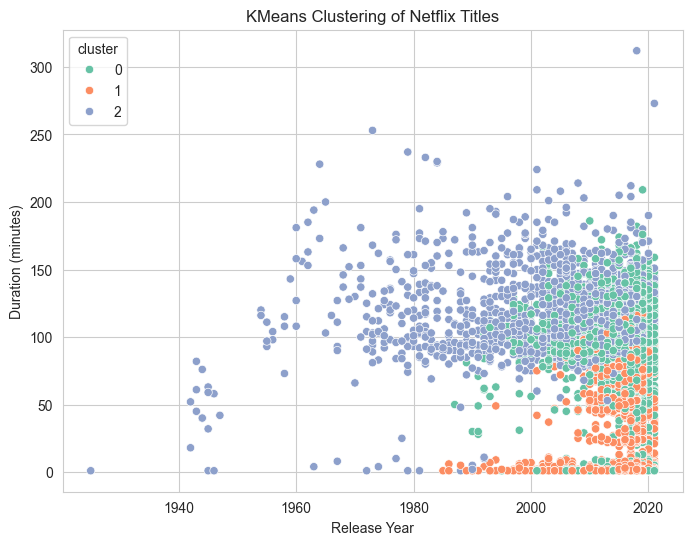

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['release_year'],
    y=df['duration_int'],
    hue=df['cluster'],
    palette='Set2'
)

plt.title("KMeans Clustering of Netflix Titles")
plt.xlabel("Release Year")
plt.ylabel("Duration (minutes)")
plt.show()

In [8]:
# Step 7: Prepare data for classification

features = ['release_year', 'duration_int', 'genre_count', 'content_age']
X = df[features]
y = df['type']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 7043
Testing samples: 1761


In [9]:
# Step 8: Train Random Forest Classifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [10]:
# Step 9: Make predictions

y_pred = rf_model.predict(X_test)

print("Predictions generated.")

Predictions generated.


In [11]:
# Step 10: Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 3))

Model Accuracy: 0.998


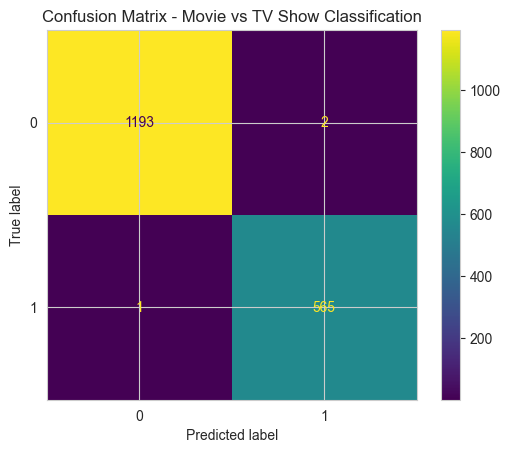

In [12]:
# Step 11: Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix - Movie vs TV Show Classification")

plt.show()

**Confusion Matrix Interpretation**

The confusion matrix shows the performance of the Random Forest classifier in predicting whether a Netflix title is a Movie or a TV Show. The model correctly classified 1193 movies and 565 TV shows, with only three misclassifications overall. This results in an accuracy of approximately 99.8%, indicating that the selected features, particularly duration, are highly effective in distinguishing between movies and TV shows.

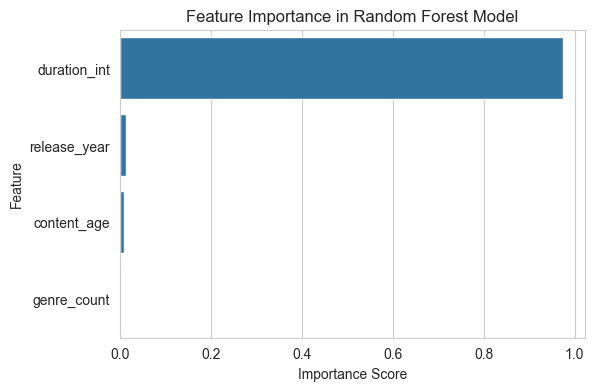

In [13]:
# Feature importance

import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=feature_importance, y=feature_importance.index)

plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()